In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
from tensorflow import keras
import os



In [2]:
df = pd.read_csv("patient_data.csv")
print("Dataset Loaded:", df.shape)
df.head()


Dataset Loaded: (200020, 17)


,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [3]:
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

In [4]:
label_encoder = LabelEncoder()
df['Risk_Category'] = label_encoder.fit_transform(df['Risk Category'])

In [5]:
features = [
    'Heart Rate', 'Respiratory Rate',
    'Body Temperature', 'Oxygen Saturation',
    'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Age', 'Gender', 'Weight (kg)', 'Height (m)',
    'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI', 'Derived_MAP'
]
target = 'Risk_Category'

X = df[features]
y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Save preprocessors
joblib.dump(scaler, "vitals_scaler.pkl")
joblib.dump(label_encoder, "risk_label_encoder.pkl")
joblib.dump(features, "feature_columns.pkl")

['feature_columns.pkl']

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_values))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.9514341435570566, 1: 1.053790632738001}


In [10]:
import time

model = Sequential([
    Dense(128, activation='relu', input_dim=len(features)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start_time=time.time()
history = model.fit(
    X_train_scaled, y_train,
    epochs=80, batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=1
)
end_time=time.time()
training_time=end_time-start_time
print("training_time",training_time)


C:\Users\bt354\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.9346 - loss: 0.1463 - val_accuracy: 0.9809 - val_loss: 0.0437
Epoch 2/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - accuracy: 0.9837 - loss: 0.0390 - val_accuracy: 0.9784 - val_loss: 0.0534
Epoch 3/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.9867 - loss: 0.0317 - val_accuracy: 0.9874 - val_loss: 0.0277
Epoch 4/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.9894 - loss: 0.0261 - val_accuracy: 0.9908 - val_loss: 0.0215
Epoch 5/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.9906 - loss: 0.0230 - val_accuracy: 0.9927 - val_loss: 0.0183
Epoch 6/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - accuracy: 0.9911 - loss: 0.0216 - val_accuracy: 0.9936 - val_loss: 0.0158
Epoch 7/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 52s 11ms/step - accuracy: 0.9918 - loss: 0.0192 - val_accuracy: 0.9900 - val_loss: 0.0214
Epoch 8/80
4501/4501 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.9927 - loss:

In [11]:
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step  

Accuracy: 0.9937756224377562

Classification Report:
               precision    recall  f1-score   support

   High Risk       1.00      0.99      0.99     21023
    Low Risk       0.99      0.99      0.99     18981

    accuracy                           0.99     40004
   macro avg       0.99      0.99      0.99     40004
weighted avg       0.99      0.99      0.99     40004



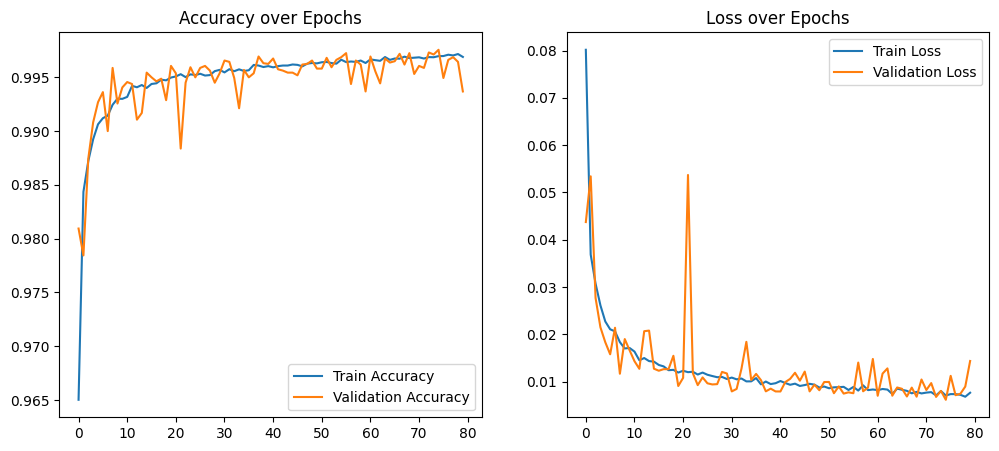

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()


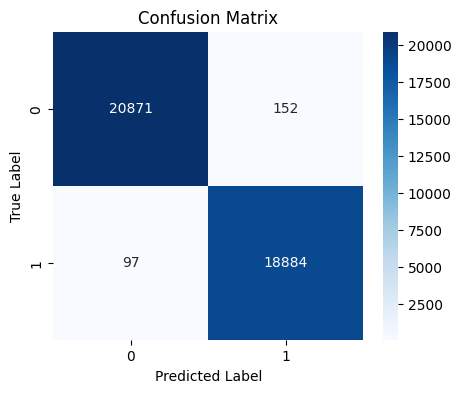

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [14]:
model.save("sehatconnect_ffnn_vitals_risk.h5")
print("Model and Preprocessing Files Saved Successfully!")

Model and Preprocessing Files Saved Successfully!


In [15]:
import os
print(os.path.exists("sehatconnect_ffnn_vitals_risk.h5"))


True


In [16]:
def predict_risk(patient_data):
    # Load saved model and preprocessing tools
    model = tf.keras.models.load_model("sehatconnect_ffnn_vitals_risk.h5")
    scaler = joblib.load("vitals_scaler.pkl")
    encoder = joblib.load("risk_label_encoder.pkl")
    features = joblib.load("feature_columns.pkl")

    # Ensure correct column order
    for col in features:
        if col not in patient_data.columns:
            patient_data[col] = 0
    patient_data = patient_data[features]


    # Scale and predict
    scaled = scaler.transform(patient_data)
    pred = (model.predict(scaled) > 0.5).astype(int)
    risk_label = encoder.inverse_transform(pred.flatten())
    return risk_label

In [17]:

example_patients = pd.DataFrame([
    [75, 16, 36.8, 98, 120, 80, 37, 0, 70, 1.75, 0.11, 40, 22.8, 93.3],
    [105, 18, 37.0, 97, 150, 95, 50, 1, 85, 1.68, 0.09, 55, 30.0, 113.3],
    [80, 20, 36.9, 96, 135, 82, 40, 0, 78, 1.65, 0.08, 50, 26.5, 98.0],
    [70, 15, 36.7, 97, 120, 80, 25, 1, 45, 1.80, 0.12, 40, 13.9, 86.7],
    [82, 17, 36.9, 96, 135, 82, 40, 0, 78, 1.65, 0.08, 50, 26.5, 98.0]
], columns=features)
example_patients['Model_Predicted_Risk'] = predict_risk(example_patients)


example_patients


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Model_Predicted_Risk
0,75,16,36.8,98,120,80,37,0,70,1.75,0.11,40,22.8,93.3,Low Risk
1,105,18,37.0,97,150,95,50,1,85,1.68,0.09,55,30.0,113.3,High Risk
2,80,20,36.9,96,135,82,40,0,78,1.65,0.08,50,26.5,98.0,Low Risk
3,70,15,36.7,97,120,80,25,1,45,1.80,0.12,40,13.9,86.7,High Risk
4,82,17,36.9,96,135,82,40,0,78,1.65,0.08,50,26.5,98.0,Low Risk
